In [1]:
import pandas as pd

df = pd.read_csv('./save_annotations_df_Olivine.csv')
feret_mins = df['feret_min_mm']
feret_maxes = df['feret_max_mm']
touch_edges = df['touch_edge']

In [2]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

def estimate_third_dimension_probabilistic(dim1s, dim2s, num_samples=1000):
    """
    Estimate the third dimension probabilistically based on observed dim1 and dim2 distributions.

    Parameters:
        dim1s (list): List of smaller dimensions observed in the profile.
        dim2s (list): List of larger dimensions observed in the profile.
        num_samples (int): Number of samples to generate for the third dimension.

    Returns:
        dict: A dictionary containing KDEs for the third dimension conditioned on dim1 and dim2.
    """
    # Ensure dim1s and dim2s are numpy arrays
    dim1s = np.array(dim1s)
    dim2s = np.array(dim2s)
    
    # Generate plausible third dimensions
    third_dimensions = []
    for dim1, dim2 in zip(dim1s, dim2s):
        # Sample plausible third dimensions between dim1 and dim2
        samples = np.random.uniform(low=dim1, high=dim2, size=num_samples)
        third_dimensions.extend(samples)
    
    # Fit a KDE to the third dimension samples
    kde = gaussian_kde(third_dimensions)
    
    return kde

def predict_third_dimension(kde, dim1, dim2, num_samples=1000):
    """
    Predict the third dimension for a grain given dim1 and dim2.

    Parameters:
        kde (gaussian_kde): KDE model for estimating the third dimension.
        dim1 (float): Observed smaller dimension for the grain.
        dim2 (float): Observed larger dimension for the grain.
        num_samples (int): Number of samples to generate for prediction.

    Returns:
        float: Estimated third dimension (e.g., the mode of the distribution).
    """
    # Generate plausible third dimensions between dim1 and dim2
    samples = np.random.uniform(low=dim1, high=dim2, size=num_samples)
    
    # Evaluate the KDE on the samples
    densities = kde(samples)
    
    # Return the sample corresponding to the maximum density
    return samples[np.argmax(densities)]

In [3]:
def plot_third_dimension_distribution(kde, dim1_range, dim2_range):
    """
    Plot the KDE for the third dimension.

    Parameters:
        kde (gaussian_kde): KDE model for estimating the third dimension.
        dim1_range (tuple): Range of dim1 values to plot.
        dim2_range (tuple): Range of dim2 values to plot.
    """
    # Generate a range of plausible third dimensions
    third_dim_vals = np.linspace(dim1_range[0], dim2_range[1], 1000)
    
    # Evaluate the KDE
    densities = kde(third_dim_vals)
    
    # Plot the distribution
    plt.figure(figsize=(10, 6))
    plt.plot(third_dim_vals, densities, label='Third Dimension KDE')
    plt.xlabel('Third Dimension')
    plt.ylabel('Density')
    plt.title('Estimated Third Dimension Distribution')
    plt.legend()
    plt.show()

In [4]:
# Fit the KDE for the third dimension
kde = estimate_third_dimension_probabilistic(feret_mins, feret_maxes)

In [5]:
def predict_third_dimension(kde, dim1, dim2, num_samples=10):
    """
    Predict the third dimension for a grain given dim1 and dim2.

    Parameters:
        kde (gaussian_kde): KDE model for estimating the third dimension.
        dim1 (float): Observed smaller dimension for the grain.
        dim2 (float): Observed larger dimension for the grain.
        num_samples (int): Number of samples to generate.

    Returns:
        float: Estimated third dimension (e.g., the mode of the distribution).
    """
    # Generate a fixed grid of plausible third dimensions
    samples = np.linspace(dim1, dim2, num_samples)
    
    # Evaluate the KDE on the grid
    densities = kde(samples)
    
    # Return the sample corresponding to the maximum density
    return samples[np.argmax(densities)]

In [8]:
from sklearn.neighbors import KernelDensity

def fit_kde_sklearn(data, bandwidth=0.1):
    """
    Fit a KDE using sklearn's KernelDensity.

    Parameters:
        data (list): Data points to fit the KDE.
        bandwidth (float): Bandwidth for the KDE.

    Returns:
        KernelDensity: Fitted KDE model.
    """
    kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
    kde.fit(np.array(data).reshape(-1, 1))  # Reshape data to 2D array
    return kde

def predict_third_dimension_sklearn(kde, dim1, dim2, num_samples=200):
    """
    Predict the third dimension using sklearn's KernelDensity.

    Parameters:
        kde (KernelDensity): Fitted KDE model.
        dim1 (float): Observed smaller dimension for the grain.
        dim2 (float): Observed larger dimension for the grain.
        num_samples (int): Number of samples to generate.

    Returns:
        float: Estimated third dimension (e.g., the mode of the distribution).
    """
    # Generate a fixed grid of plausible third dimensions
    samples = np.linspace(dim1, dim2, num_samples).reshape(-1, 1)
    
    # Evaluate the KDE on the grid
    log_densities = kde.score_samples(samples)  # Log densities from sklearn KDE
    
    # Return the sample corresponding to the maximum density
    return samples[np.argmax(log_densities)][0]

In [11]:
# Combine dim1s and dim2s into a single dataset for KDE fitting
combined_dimensions = feret_mins + feret_maxes

# Fit the KDE using sklearn
kde = fit_kde_sklearn(combined_dimensions, bandwidth=0.1)

In [12]:
predicted_third_dim = predict_third_dimension_sklearn(kde, feret_mins[0], feret_maxes[0])
print(f"Predicted third dimension: {predicted_third_dim}")

Predicted third dimension: 0.0599975715280977


In [14]:
def plot_kde_sklearn(kde, dim1_range, dim2_range, num_points=1000):
    """
    Plot the KDE for the third dimension using sklearn.neighbors.KernelDensity.

    Parameters:
        kde (KernelDensity): KDE model for estimating the third dimension.
        dim1_range (tuple): Range of dim1 values to plot (min, max).
        dim2_range (tuple): Range of dim2 values to plot (min, max).
        num_points (int): Number of points to evaluate the KDE.

    Returns:
        None: Displays the plot.
    """
    # Generate a range of plausible third dimensions
    third_dim_vals = np.linspace(dim1_range[0], dim2_range[1], num_points).reshape(-1, 1)
    
    # Evaluate the KDE on the range (log densities)
    log_densities = kde.score_samples(third_dim_vals)
    
    # Convert log densities to actual densities
    densities = np.exp(log_densities)
    
    # Plot the KDE
    plt.figure(figsize=(10, 6))
    plt.plot(third_dim_vals, densities, label='Third Dimension KDE')
    plt.xlabel('Third Dimension')
    plt.ylabel('Density')
    plt.title('Estimated Third Dimension Distribution')
    plt.legend()
    plt.show()

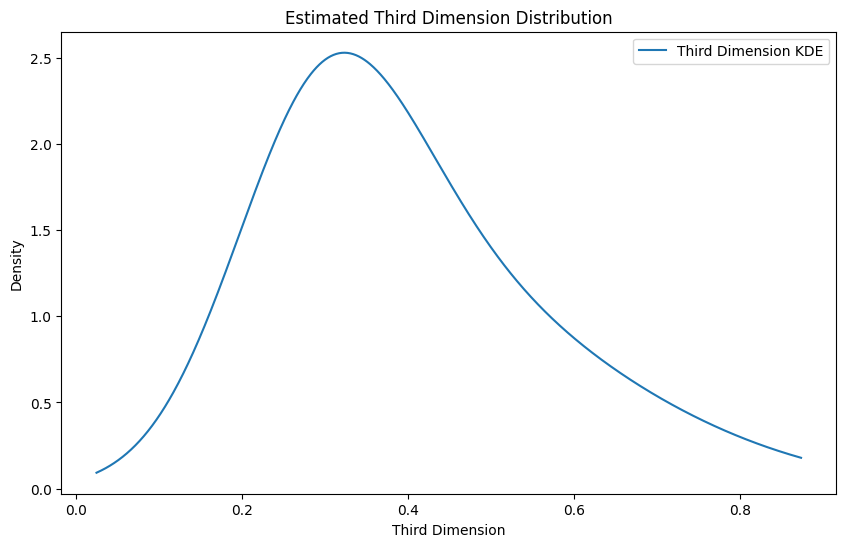

In [15]:
# Plot the third dimension distribution
plot_kde_sklearn(kde, (min(feret_mins), max(feret_mins)), (min(feret_maxes), max(feret_maxes)))

In [16]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

def log_normal_cdf(x, mu, sigma):
    """
    Log-normal cumulative distribution function (CDF).
    """
    return 0.5 * (1 + np.erf((np.log(x) - mu) / (sigma * np.sqrt(2))))

def fit_cumulative_distribution(sizes, cumulative_percent):
    """
    Fit a log-normal cumulative distribution model to the data.

    Parameters:
        sizes (list): Grain sizes (x-axis of cumulative distribution).
        cumulative_percent (list): Cumulative percentages (y-axis of cumulative distribution).

    Returns:
        tuple: Fitted parameters (mu, sigma) for the log-normal CDF.
    """
    # Normalize cumulative_percent to range [0, 1]
    cumulative_percent = np.array(cumulative_percent) / 100.0
    
    # Fit the log-normal CDF to the data
    popt, _ = curve_fit(log_normal_cdf, sizes, cumulative_percent, p0=[np.mean(np.log(sizes)), np.std(np.log(sizes))])
    return popt

def plot_cumulative_fit(sizes, cumulative_percent, mu, sigma):
    """
    Plot the fitted cumulative distribution against the real data.

    Parameters:
        sizes (list): Grain sizes (x-axis of cumulative distribution).
        cumulative_percent (list): Cumulative percentages (y-axis of cumulative distribution).
        mu (float): Fitted mean parameter for the log-normal CDF.
        sigma (float): Fitted standard deviation parameter for the log-normal CDF.
    """
    # Generate fitted cumulative distribution
    fitted_cdf = log_normal_cdf(sizes, mu, sigma) * 100  # Scale back to percentage
    
    # Plot the real data and fitted curve
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, cumulative_percent, 'o', label='Real Data')
    plt.plot(sizes, fitted_cdf, '-', label='Fitted Log-Normal CDF')
    plt.xlabel('Grain Size')
    plt.ylabel('Cumulative Percent Passing')
    plt.title('Cumulative Distribution Fit')
    plt.legend()
    plt.show()

In [17]:
def sample_third_dimension_from_cdf(dim1, dim2, mu, sigma, num_samples=1000):
    """
    Sample plausible third dimensions consistent with the fitted cumulative distribution.

    Parameters:
        dim1 (float): Observed smaller dimension for the grain.
        dim2 (float): Observed larger dimension for the grain.
        mu (float): Fitted mean parameter for the log-normal CDF.
        sigma (float): Fitted standard deviation parameter for the log-normal CDF.
        num_samples (int): Number of samples to generate.

    Returns:
        np.ndarray: Array of sampled third dimensions.
    """
    # Generate random samples from the log-normal distribution
    samples = np.random.lognormal(mean=mu, sigma=sigma, size=num_samples)
    
    # Filter samples to ensure they lie between dim1 and dim2
    valid_samples = samples[(samples >= dim1) & (samples <= dim2)]
    
    return valid_samples

In [18]:
def validate_against_cumulative_distribution(estimated_sizes, sizes, cumulative_percent):
    """
    Validate the estimated size distribution against the real cumulative distribution.

    Parameters:
        estimated_sizes (list): Estimated grain sizes (including third dimensions).
        sizes (list): Grain sizes from the real cumulative distribution.
        cumulative_percent (list): Cumulative percentages from the real data.

    Returns:
        None: Plots the comparison.
    """
    # Calculate the cumulative distribution for the estimated sizes
    estimated_sizes = np.sort(estimated_sizes)
    estimated_cumulative_percent = np.arange(1, len(estimated_sizes) + 1) / len(estimated_sizes) * 100
    
    # Plot the comparison
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, cumulative_percent, 'o', label='Real Data')
    plt.plot(estimated_sizes, estimated_cumulative_percent, '-', label='Estimated Distribution')
    plt.xlabel('Grain Size')
    plt.ylabel('Cumulative Percent Passing')
    plt.title('Validation Against Real Cumulative Distribution')
    plt.legend()
    plt.show()